In [28]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt

In [10]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "gold_eda_data.csv"
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "selected_features.csv"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])

selected_features = pd.read_csv(FEATURES_PATH)["feature"].tolist()

print("Dataset shape:", df.shape)
print("Selected features:", len(selected_features))

Dataset shape: (1717, 82)
Selected features: 56


In [11]:
target_column = "target_next_price"

X = df[selected_features]
y = df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1717, 56)
y shape: (1717,)


In [13]:
train_size = int(len(df) * 0.70)
validation_size = int(len(df) * 0.15)

train_end = train_size
validation_end = train_size + validation_size

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:validation_end]
y_val = y.iloc[train_end:validation_end]

X_test = X.iloc[validation_end:]
y_test = y.iloc[validation_end:]

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_val.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1201
Validation rows: 257
Testing rows: 259


In [14]:
print("Training dates:", df["Date"].iloc[:train_end].min(), "to", df["Date"].iloc[:train_end].max())
print("Validation dates:", df["Date"].iloc[train_end:validation_end].min(), "to", df["Date"].iloc[train_end:validation_end].max())
print("Testing dates:", df["Date"].iloc[validation_end:].min(), "to", df["Date"].iloc[validation_end:].max())

Training dates: 2011-12-15 00:00:00 to 2016-11-30 00:00:00
Validation dates: 2016-12-01 00:00:00 to 2017-12-12 00:00:00
Testing dates: 2017-12-13 00:00:00 to 2018-12-28 00:00:00


In [23]:
def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mean_target = y_true.mean()

    mae_percentage = (mae / mean_target) * 100
    rmse_percentage = (rmse / mean_target) * 100

    return {
        "model": model_name,
        "MAE": mae,
        "MAE %": mae_percentage,
        "RMSE": rmse,
        "RMSE %": rmse_percentage,
        "R2": r2
    }

## Multiple Linear Regression without PCA

In [24]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_val_predictions = linear_model.predict(X_val)

linear_results = evaluate_model(
    "Linear Regression",
    y_val,
    linear_val_predictions
)

linear_results

{'model': 'Linear Regression',
 'MAE': 1.7196996670640494,
 'MAE %': 1.4465471063096047,
 'RMSE': 1.9911005122358345,
 'RMSE %': 1.6748393568416304,
 'R2': 0.7630757326780743}

## Linearity Check

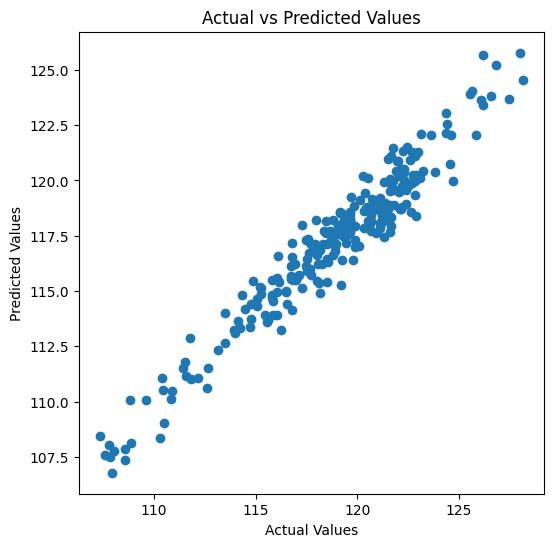

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, linear_val_predictions)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

The actual vs predicted plot shows a clear positive linear pattern, indicating that the Multiple Linear Regression model captures the overall linear relationship between the selected features and the target variable. Most points lie close to the diagonal trend, suggesting that the linearity assumption is reasonably satisfied. However, some spread around the line remains, showing that the model does not perfectly capture all variations in the target price.

## Independence of Errors check

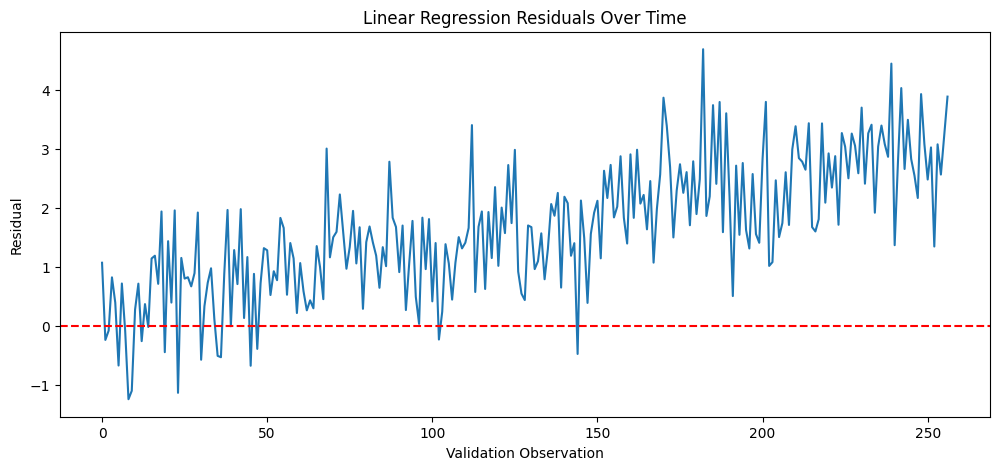

In [30]:
linear_residuals = y_val - linear_val_predictions

plt.figure(figsize=(12, 5))
plt.plot(linear_residuals.values)
plt.axhline(0, color="red", linestyle="--")
plt.title("Linear Regression Residuals Over Time")
plt.xlabel("Validation Observation")
plt.ylabel("Residual")
plt.show()

The residuals over time are not randomly distributed around zero. Instead, they show an increasing pattern, with later validation observations having larger positive residuals. This indicates that the Linear Regression model tends to underpredict gold prices in the later validation period. Therefore, the independence/randomness of residuals assumption is not fully satisfied, which suggests that the linear model may not capture time-dependent changes or changing market regimes effectively.

## Homoscedasticity check

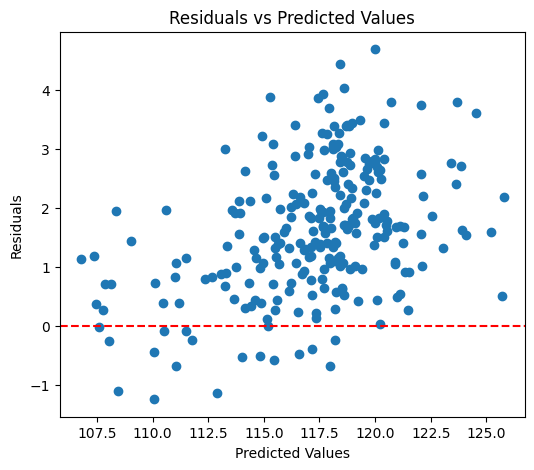

In [31]:
plt.figure(figsize=(6, 5))
plt.scatter(linear_val_predictions, linear_residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

The residuals vs predicted values plot shows that residuals are not randomly and evenly distributed around zero. Many residuals are positive, indicating that the Linear Regression model often underpredicts the actual gold price. The spread of residuals also varies across predicted values, suggesting possible heteroscedasticity. This means the constant variance assumption of Linear Regression is not fully satisfied.

## Normality of residuals check

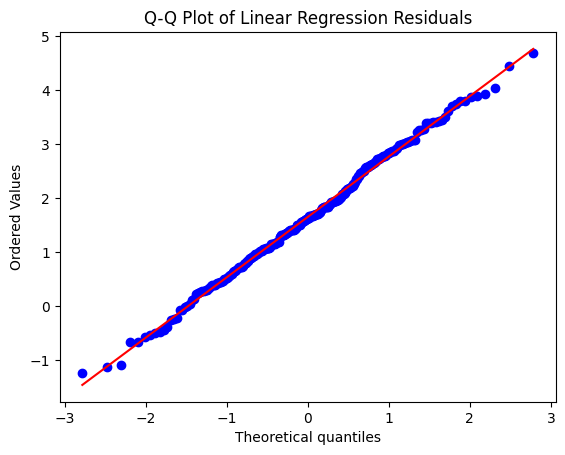

In [32]:
import scipy.stats as stats

stats.probplot(linear_residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Linear Regression Residuals")
plt.show()

The Q-Q plot shows that most residual points lie close to the reference line, indicating that the residuals are approximately normally distributed. There are minor deviations at the tails, but overall the normality assumption is reasonably satisfied for the Linear Regression model.

## Multiple Linear Regression with PCA


In [36]:
pca_linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("model", LinearRegression())
])

pca_linear_model.fit(X_train, y_train)

pca_val_predictions = pca_linear_model.predict(X_val)

pca_results = evaluate_model(
    "PCA + Linear Regression",
    y_val,
    pca_val_predictions
)

pca_results

{'model': 'PCA + Linear Regression',
 'MAE': 0.8414438257318394,
 'MAE %': 0.7077911071021578,
 'RMSE': 1.0409550968338175,
 'RMSE %': 0.8756125339571347,
 'R2': 0.9352429330430291}

## Hyperparameter Tuning

In [ ]:
pca_results_list = []

for n_components in [5, 7, 11, 15, 20]:
    pca_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", LinearRegression())
    ])

    pca_model.fit(X_train, y_train)
    val_predictions = pca_model.predict(X_val)

    result = evaluate_model(
        f"PCA + Linear Regression ({n_components})",
        y_val,
        val_predictions
    )

    result["n_components"] = n_components
    result["actual_components"] = pca_model.named_steps["pca"].n_components_

    pca_results_list.append(result)

pca_tuning_results = pd.DataFrame(pca_results_list)
pca_tuning_results.sort_values("RMSE")

,model,MAE,MAE %,RMSE,RMSE %,R2,n_components,actual_components
2,PCA + Linear Regression (11),0.826538,0.695253,1.021408,0.859170,0.937652,11,11
3,PCA + Linear Regression (15),1.203868,1.012649,1.425700,1.199245,0.878527,15,15
4,PCA + Linear Regression (20),1.223115,1.028838,1.446359,1.216623,0.874981,20,20
1,PCA + Linear Regression (7),4.572697,3.846382,5.316195,4.471785,-0.688982,7,7
0,PCA + Linear Regression (5),5.025996,4.227680,5.886604,4.951591,-1.070870,5,5


11 components is best as of now

## Random Forest Regressor

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_val_predictions = rf_model.predict(X_val)

rf_results = evaluate_model(
    "Random Forest Regressor",
    y_val,
    rf_val_predictions
)

rf_results

{'model': 'Random Forest Regressor',
 'MAE': 0.7285462913122707,
 'MAE %': 0.6128259193709016,
 'RMSE': 0.9279261255906652,
 'RMSE %': 0.7805367864807912,
 'R2': 0.9485423459548663}

## Hyperparameter Tuning

In [41]:
rf_results_list = []

for n_estimators in [100, 300, 500]:
    for max_depth in [5, 8, 12, None]:
        for min_samples_leaf in [1, 3, 5]:
            rf_model = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=42,
                n_jobs=-1
            )

            rf_model.fit(X_train, y_train)
            val_predictions = rf_model.predict(X_val)

            result = evaluate_model(
                "Random Forest Regressor",
                y_val,
                val_predictions
            )

            result["n_estimators"] = n_estimators
            result["max_depth"] = max_depth
            result["min_samples_leaf"] = min_samples_leaf

            rf_results_list.append(result)

rf_tuning_results = pd.DataFrame(rf_results_list)
rf_tuning_results.sort_values("RMSE").head(10)

,model,MAE,MAE %,RMSE,RMSE %,R2,n_estimators,max_depth,min_samples_leaf
26,Random Forest Regressor,0.656247,0.552011,0.837866,0.704782,0.958046,500,5.0,5
25,Random Forest Regressor,0.657460,0.553031,0.838917,0.705666,0.957941,500,5.0,3
24,Random Forest Regressor,0.657997,0.553483,0.839886,0.706481,0.957844,500,5.0,1
2,Random Forest Regressor,0.658149,0.553610,0.843401,0.709437,0.957490,100,5.0,5
14,Random Forest Regressor,0.662163,0.556987,0.843694,0.709684,0.957460,300,5.0,5
29,Random Forest Regressor,0.651274,0.547827,0.843879,0.709840,0.957442,500,8.0,5
13,Random Forest Regressor,0.663499,0.558111,0.845035,0.710812,0.957325,300,5.0,3
1,Random Forest Regressor,0.660940,0.555958,0.845886,0.711528,0.957239,100,5.0,3
5,Random Forest Regressor,0.647054,0.544278,0.846095,0.711703,0.957218,100,8.0,5
12,Random Forest Regressor,0.664686,0.559109,0.846370,0.711935,0.957190,300,5.0,1


Random Forest hyperparameter tuning improved the validation performance. The best model used 500 estimators, a maximum depth of 5, and a minimum leaf size of 5.

## Combined Train and Validation Set 

In [42]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

## Final Model 2: PCA + Tuned Linear Regression

In [ ]:
final_pca_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=11)),
    ("model", LinearRegression())
])

final_pca_model.fit(X_train_val, y_train_val)

pca_test_predictions = final_pca_model.predict(X_test)

pca_test_results = evaluate_model(
    "Final PCA + Linear Regression",
    y_test,
    pca_test_predictions
)

pca_test_results

{'model': 'Final PCA + Linear Regression',
 'MAE': 0.5901162496484059,
 'MAE %': 0.49080136160900967,
 'RMSE': 0.7672766789208326,
 'RMSE %': 0.6381461940245706,
 'R2': 0.9772214599294904}

## Final Model 3: Tuned Random Forest

In [44]:
final_rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_train_val, y_train_val)

rf_test_predictions = final_rf_model.predict(X_test)

rf_test_results = evaluate_model(
    "Final Tuned Random Forest Regressor",
    y_test,
    rf_test_predictions
)

rf_test_results

{'model': 'Final Tuned Random Forest Regressor',
 'MAE': 0.628004469292456,
 'MAE %': 0.5223131015438451,
 'RMSE': 0.8081131176209108,
 'RMSE %': 0.6721099761254747,
 'R2': 0.974732271472611}

In [45]:
final_test_results = pd.DataFrame([
    pca_test_results,
    rf_test_results
])

final_test_results.sort_values("RMSE")

,model,MAE,MAE %,RMSE,RMSE %,R2
0,Final PCA + Linear Regression,0.590116,0.490801,0.767277,0.638146,0.977221
1,Final Tuned Random Forest Regressor,0.628004,0.522313,0.808113,0.672110,0.974732


Although the tuned Random Forest performed best on the validation set, PCA + Linear Regression achieved slightly lower RMSE on the final test set. This indicates that the PCA-based model generalized slightly better to the unseen test period. However, both models performed very well, with percentage errors below 1%.